In [192]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit


In [193]:
preds_dir = '../preds/'
dataset_dir = '../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)


[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [194]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [195]:
files = os.listdir(preds_dir)
print(files)

['EDSR_ws_temp_2018_4x.pt', 'EDSR_ws_temp_2012_8x.pt', 'EDSR_ws_temp_2006_4x.pt', 'baseline_2016_4x.pt', 'baseline_2020_8x.pt', 'EDSR_ws_temp_2020_4x.pt', 'EDSR_ws_temp_2022_4x.pt', 'EDSR_ws_temp_1990_8x.pt', 'EDSR_2023_8x.pt', 'baseline_2002_4x.pt', 'EDSR_ws_temp_2000_8x.pt', 'EDSR_ws_temp_1986_8x.pt', 'EDSR_ws_temp_2009_8x.pt', 'EDSR_2000_8x.pt', 'EDSR_ws_temp_1989_4x.pt', 'EDSR_ws_temp_2016_8x.pt', 'baseline_1996_4x.pt', 'EDSR_ws_temp_2017_8x.pt', 'EDSR_2013_4x.pt', 'EDSR_ws_temp_1994_8x.pt', 'EDSR_1999_8x.pt', 'baseline_1994_8x.pt', 'baseline_2009_8x.pt', 'EDSR_ws_temp_2005_8x.pt', 'EDSR_ws_temp_1987_4x.pt', 'baseline_2009_2x.pt', 'EDSR_ws_temp_2018_8x.pt', 'EDSR_ws_temp_2021_4x.pt', 'baseline_1997_4x.pt', 'EDSR_ws_temp_2004_8x.pt', 'EDSR_1991_4x.pt', 'EDSR_2000_4x.pt', 'EDSR_2020_4x.pt', 'EDSR_2006_8x.pt', 'EDSR_1990_4x.pt', 'EDSR_1994_4x.pt', 'EDSR_2022_8x.pt', 'EDSR_ws_temp_2022_8x.pt', 'baseline_2018_4x.pt', 'baseline_1991_8x.pt', 'baseline_2015_8x.pt', 'EDSR_1983_8x.pt', 'EDSR

# Ground Truth

In [196]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


# Low res input

In [197]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


# Model Output

In [198]:
def is_leap_year(field):
    return field.shape[0] == 1464

In [199]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


# Compare 


In [200]:
longitudes = eval_split.longitude.values[:32]
latitudes = eval_split.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


355


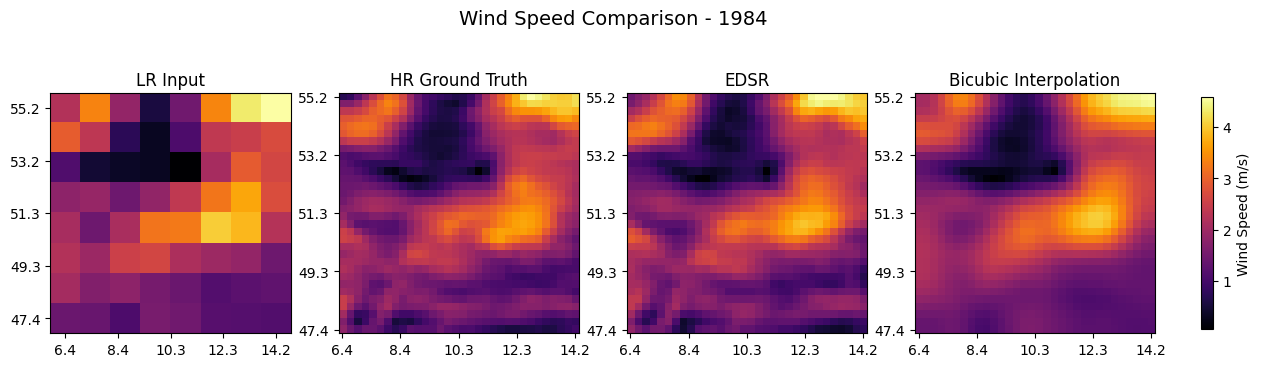

In [201]:
def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 8))
    fields = [field[index] for field in fields]
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        ax[i].set_title(names[i])
        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks])
        ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks])
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    plt.suptitle(f"Wind Speed Comparison - {TEST_YEAR}", fontsize=14, y=.75)
    plt.show()

ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)

index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, 609)

In [202]:
print(np.mean(ground_truth_wind_speeds))
print(np.std(ground_truth_wind_speeds))
print(np.min(ground_truth_wind_speeds))
print(np.max(ground_truth_wind_speeds))

3.7423608
2.4426157
0.0011898181
23.356188


In [203]:
# Metrics in original range
edsr, baseline = ws_fields[names.index("EDSR")], ws_fields[names.index("Bicubic Interpolation")]
mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
print(f"Baseline: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")


EDSR: MSE: 0.0540, MAE: 0.1612
Baseline: MSE: 0.1994, MAE: 0.3041


# Compare Metrics over years

In [204]:

ws_dict = {year: {} for year in years}
for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        ws_dict[year]['EDSR'] = edsr
        ws_dict[year]['Baseline'] = baseline
        ws_dict[year]['Ground Truth'] = ground_truth_wind_speeds


In [205]:
def get_metrics_over_time(years):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        edsr, baseline = ws_dict[year]['EDSR'], ws_dict[year]['Baseline']
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    
    for i, model in enumerate(mses):
        # Plot MSE for the current model
        ax[i, 0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color='blue')
        ax[i, 0].set_title(f'{model} - MSE')
        ax[i, 0].set_xlabel('Year')
        ax[i, 0].set_ylabel('MSE')
        ax[i, 0].legend()
        ax[i, 0].grid(True)

        # Plot MAE for the current model
        ax[i, 1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color='orange')
        ax[i, 1].set_title(f'{model} - MAE')
        ax[i, 1].set_xlabel('Year')
        ax[i, 1].set_ylabel('MAE')
        ax[i, 1].legend()
        ax[i, 1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score', color='blue')
    ax[0].set_title('MSE Skill Score')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score', color='orange')
    ax[1].set_title('MAE Skill Score')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    

In [206]:

mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

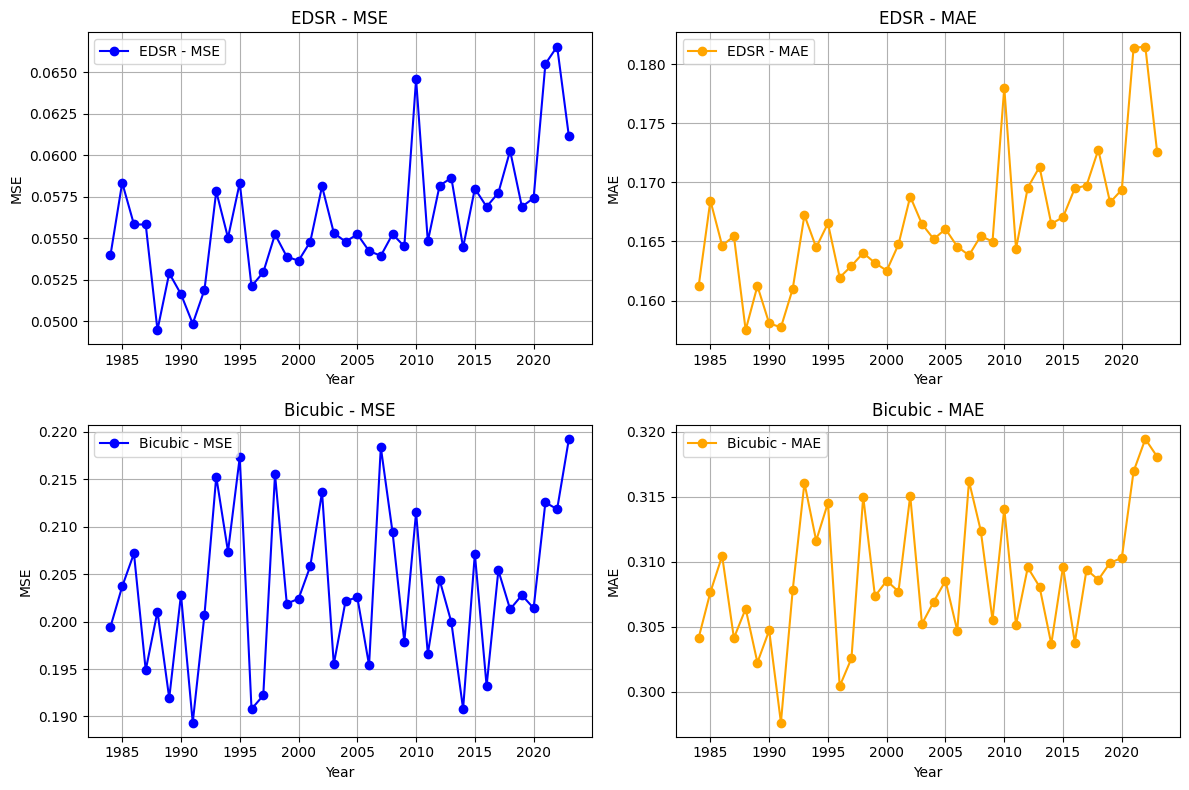

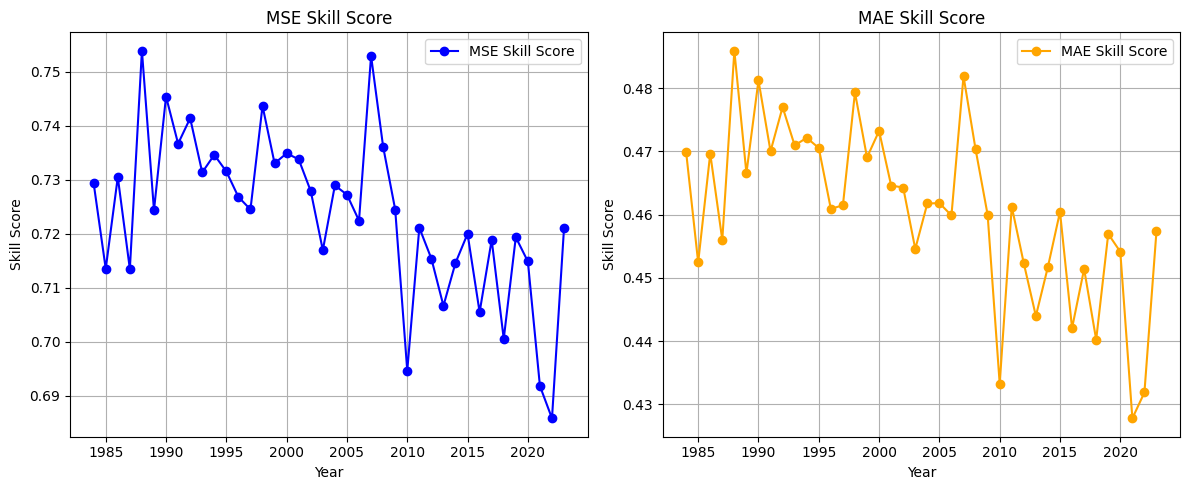

In [207]:
plot_metrics_over_time(years, mses, maes)
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)

In [208]:
error_images = {"bicubic" : [], "edsr" : [], "edsr_bias" : []}
top_percentile_error = {"bicubic" : [], "edsr" : []}
bias_per_year = {"bicubic" : [], "edsr" : [], "bicubic_90th": [], "edsr_90th": []}
mean_ws_per_pixel_per_year = []
for year in years:
        edsr = ws_dict[year]['EDSR']
        baseline = ws_dict[year]['Baseline']
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']

        edsr_error = np.abs(edsr - ground_truth_wind_speeds).mean(axis=0)
        baseline_error = np.abs(baseline - ground_truth_wind_speeds).mean(axis=0)
        
        bias_edsr = (edsr - ground_truth_wind_speeds).mean(axis=0)
        error_images["bicubic"].append(baseline_error)
        error_images["edsr"].append(edsr_error)
        error_images["edsr_bias"].append(bias_edsr)
        #look at extreme conditions (90th percentile) 
        mask = np.where(ground_truth_wind_speeds >= np.percentile(ground_truth_wind_speeds, 90))
        
        top_percentile_error["bicubic"].append(np.abs(baseline - ground_truth_wind_speeds)[mask].mean())
        top_percentile_error["edsr"].append(np.abs(edsr - ground_truth_wind_speeds)[mask].mean())
        
        bias_per_year['bicubic'].append((baseline - ground_truth_wind_speeds).mean())
        bias_per_year['edsr'].append((edsr - ground_truth_wind_speeds).mean())
        bias_per_year['bicubic_90th'].append((baseline - ground_truth_wind_speeds)[mask].mean())
        bias_per_year['edsr_90th'].append((edsr - ground_truth_wind_speeds)[mask].mean())
        
        mean_ws_per_pixel_per_year.append(ground_truth_wind_speeds.mean(axis=0))

/tmp/ipykernel_71983/2264264894.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  edsr_error = np.abs(edsr - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_71983/2264264894.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  baseline_error = np.abs(baseline - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_71983/2264264894.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bias_edsr = (edsr - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_71983/2264264894.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  top_percentile_error["bicubic"].append(np.abs(baseline - ground_truth_wind_speeds)[mask].mean

In [209]:
def get_stats_over_time(years):
    gt_statistics = {'mean': [], 'var': [], 'std' :[]}

    for year in years:
        _, gt_ws, _ = get_ground_truth_ws(data_dir=dataset_dir,
                                            train_start=TRAIN_START,
                                            train_end=TRAIN_END,
                                            test_year=year)
        gt_statistics['mean'].append(gt_ws.mean())
        gt_statistics['var'].append(gt_ws.var())
        gt_statistics['std'].append(gt_ws.std())
        
    return gt_statistics

gt_stats = get_stats_over_time(years)


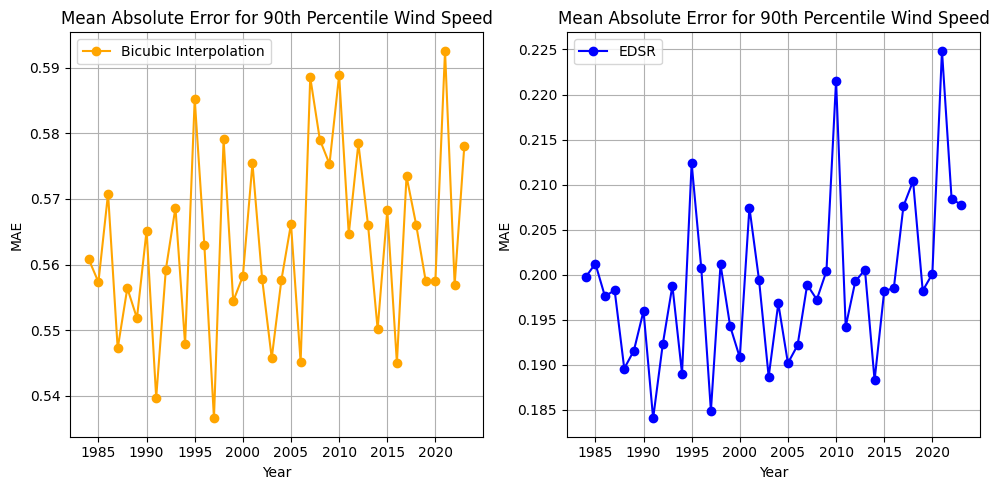

In [210]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(years, top_percentile_error["bicubic"], 'o-', label='Bicubic Interpolation', color='orange')
ax[0].set_title('Mean Absolute Error for 90th Percentile Wind Speed')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('MAE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years, top_percentile_error["edsr"], 'o-', label='EDSR', color='blue')
ax[1].set_title('Mean Absolute Error for 90th Percentile Wind Speed')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('MAE')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Correlation between wind speed field of 1984 and following years

In [211]:
reference_year_gt = ws_dict[1984]['Ground Truth'].mean(axis=0)
reference_year_edsr = ws_dict[1984]['EDSR'].mean(axis=0)
ssim_over_time = {"Ground Truth": [], "EDSR": []}   
pearson_over_time = {"Ground Truth": [], "EDSR": []}
spearman_over_time = {"Ground Truth": [], "EDSR": []}    
for year in years[1:]:
    current_year_gt = ws_dict[year]['Ground Truth'].mean(axis=0)
    current_year_edsr = ws_dict[year]['EDSR'].mean(axis=0)
    ssim_over_time["Ground Truth"].append(get_SSIM(current_year_gt, reference_year_gt))
    ssim_over_time["EDSR"].append(get_SSIM(current_year_edsr, reference_year_edsr))
    
    pearson_over_time["Ground Truth"].append(get_correlation(current_year_gt, reference_year_gt, method="pearson")[0])
    pearson_over_time["EDSR"].append(get_correlation(current_year_edsr, reference_year_gt, method="pearson")[0])    
    
    spearman_over_time["Ground Truth"].append(get_correlation(current_year_gt, reference_year_gt, method="spearman")[0])
    spearman_over_time["EDSR"].append(get_correlation(current_year_edsr, reference_year_gt, method="spearman")[0])

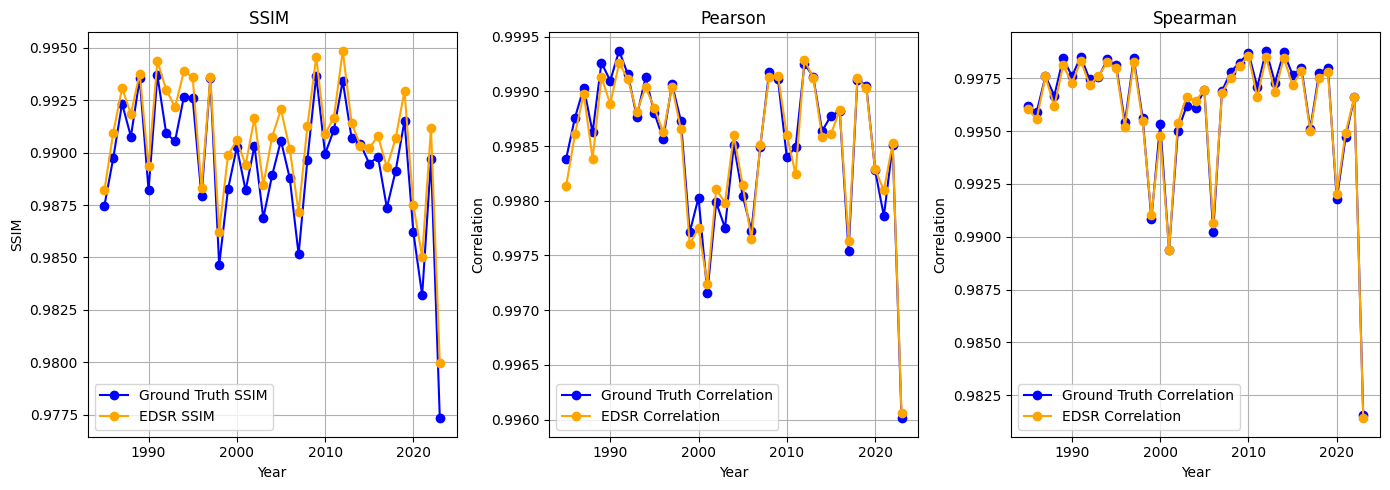

In [212]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

# Plot SSIM over time on the first subplot
ax[0].plot(years[1:], ssim_over_time["Ground Truth"], 'o-', label='Ground Truth SSIM', color='blue')
ax[0].plot(years[1:], ssim_over_time["EDSR"], 'o-', label='EDSR SSIM', color='orange')
ax[0].set_title('SSIM ')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('SSIM')
ax[0].legend()
ax[0].grid(True)

# Plot Correlation over time on the second subplot
ax[1].plot(years[1:], pearson_over_time["Ground Truth"], 'o-', label='Ground Truth Correlation', color='blue')
ax[1].plot(years[1:], pearson_over_time["EDSR"], 'o-', label='EDSR Correlation', color='orange')
ax[1].set_title('Pearson')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Correlation')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(years[1:], spearman_over_time["Ground Truth"], 'o-', label='Ground Truth Correlation', color='blue')
ax[2].plot(years[1:], spearman_over_time["EDSR"], 'o-', label='EDSR Correlation', color='orange')
ax[2].set_title('Spearman')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Correlation')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()


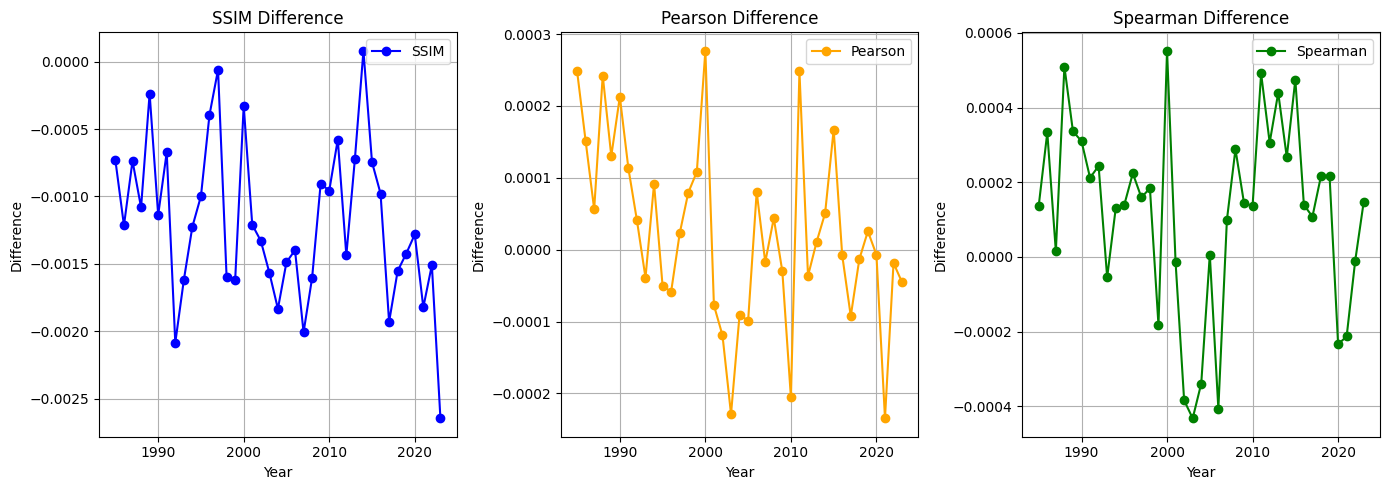

In [213]:
# plot differnce between gt and edsr correlations
fig, ax = plt.subplots(1, 3, figsize=(14, 5))
diff_pearson = np.array(pearson_over_time["Ground Truth"]) - np.array(pearson_over_time["EDSR"])
diff_spearman = np.array(spearman_over_time["Ground Truth"]) - np.array(spearman_over_time["EDSR"])
diff_ssim = np.array(ssim_over_time["Ground Truth"]) - np.array(ssim_over_time["EDSR"])

ax[0].plot(years[1:], diff_ssim, 'o-', label='SSIM', color='blue')
ax[0].set_title('SSIM Difference')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Difference')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years[1:], diff_pearson, 'o-', label='Pearson', color='orange')
ax[1].set_title('Pearson Difference')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Difference')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(years[1:], diff_spearman, 'o-', label='Spearman', color='green')
ax[2].set_title('Spearman Difference')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Difference')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()



# Error per pixel

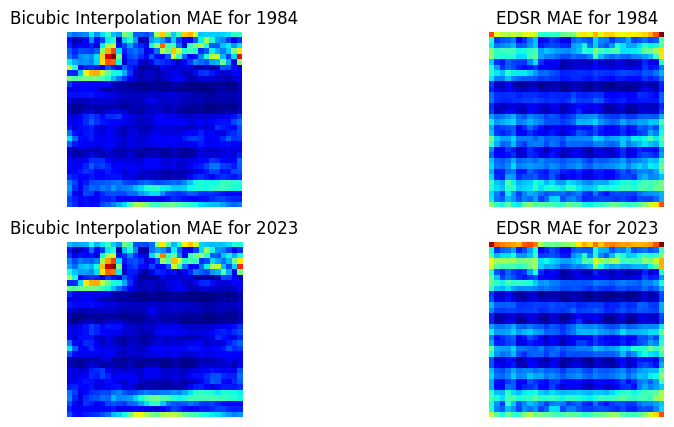

In [214]:
#plot error images
fig, ax = plt.subplots(2, 2, figsize=(10,5))
ax[0, 0].imshow(error_images["bicubic"][0], cmap='jet')
ax[0, 0].set_title('Bicubic Interpolation MAE for 1984')
ax[0, 0].axis('off')

ax[0, 1].imshow(error_images["edsr"][0], cmap='jet')
ax[0, 1].set_title('EDSR MAE for 1984')
ax[0, 1].axis('off')

ax[1, 0].imshow(error_images["bicubic"][-1], cmap='jet')
ax[1, 0].set_title('Bicubic Interpolation MAE for 2023')
ax[1, 0].axis('off')

ax[1, 1].imshow(error_images["edsr"][-1], cmap='jet')
ax[1, 1].set_title('EDSR MAE for 2023')
ax[1, 1].axis('off')
#im = ax[0, 0].imshow(error_images["edsr"][0], cmap='jet')
#cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
#plt.tight_layout()
plt.show()

# Normalize Error per Pixel by Mean WS

/tmp/ipykernel_71983/1513099136.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_error_images["edsr"].append(error_images["edsr"][i] / mean_ws_per_pixel_per_year[i])
/tmp/ipykernel_71983/1513099136.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_error_images["bicubic"].append(error_images["bicubic"][i] / mean_ws_per_pixel_per_year[i])


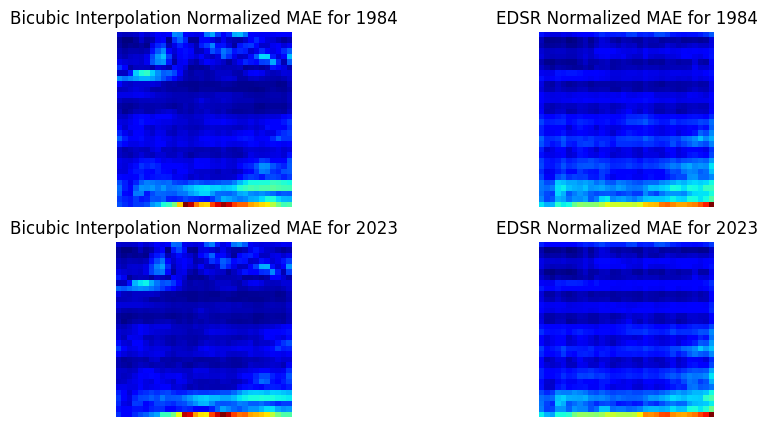

In [215]:
normalized_error_images = {"bicubic": [], "edsr": []}
for i in range(len(years)):
    normalized_error_images["edsr"].append(error_images["edsr"][i] / mean_ws_per_pixel_per_year[i])
    normalized_error_images["bicubic"].append(error_images["bicubic"][i] / mean_ws_per_pixel_per_year[i])

fig, ax = plt.subplots(2, 2, figsize=(10,5))
ax[0, 0].imshow(normalized_error_images["bicubic"][0], cmap='jet')
ax[0, 0].set_title('Bicubic Interpolation Normalized MAE for 1984')
ax[0, 0].axis('off')

ax[0, 1].imshow(normalized_error_images["edsr"][0], cmap='jet')
ax[0, 1].set_title('EDSR Normalized MAE for 1984')
ax[0, 1].axis('off')

ax[1, 0].imshow(normalized_error_images["bicubic"][-1], cmap='jet')
ax[1, 0].set_title('Bicubic Interpolation Normalized MAE for 2023')
ax[1, 0].axis('off')

ax[1, 1].imshow(normalized_error_images["edsr"][-1], cmap='jet')
ax[1, 1].set_title('EDSR Normalized MAE for 2023')
ax[1, 1].axis('off')

plt.show()


# Bias per Pixel


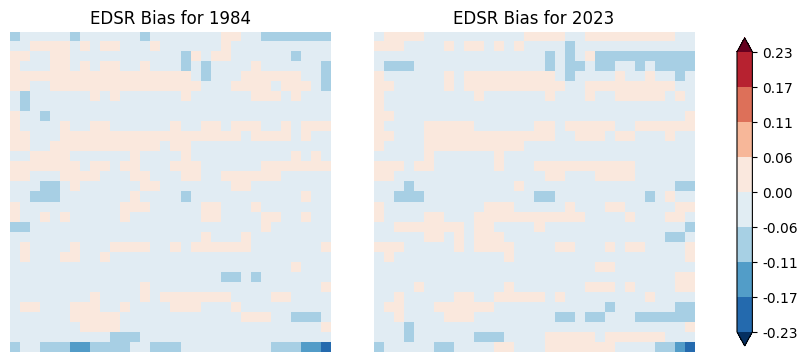

In [216]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

vmina, vmaxa = error_images["edsr_bias"][0].min(), error_images["edsr_bias"][0].max()
vminb, vmaxb = error_images["edsr_bias"][-1].min(), error_images["edsr_bias"][-1].max()

abs_max = max(abs(vmina), abs(vmaxa), abs(vminb), abs(vmaxb))
vmin, vmax = -abs_max, abs_max

levels = np.linspace(vmin, vmax, num=9)  

cmap = plt.cm.RdBu_r  
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

im1 = ax1.imshow(error_images["edsr_bias"][0], cmap=cmap, norm=norm)
ax1.set_title('EDSR Bias for 1984')
ax1.axis('off')

im2 = ax2.imshow(error_images["edsr_bias"][-1], cmap=cmap, norm=norm)
ax2.set_title('EDSR Bias for 2023')
ax2.axis('off')

cbar = fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', ticks=levels, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])

plt.show()


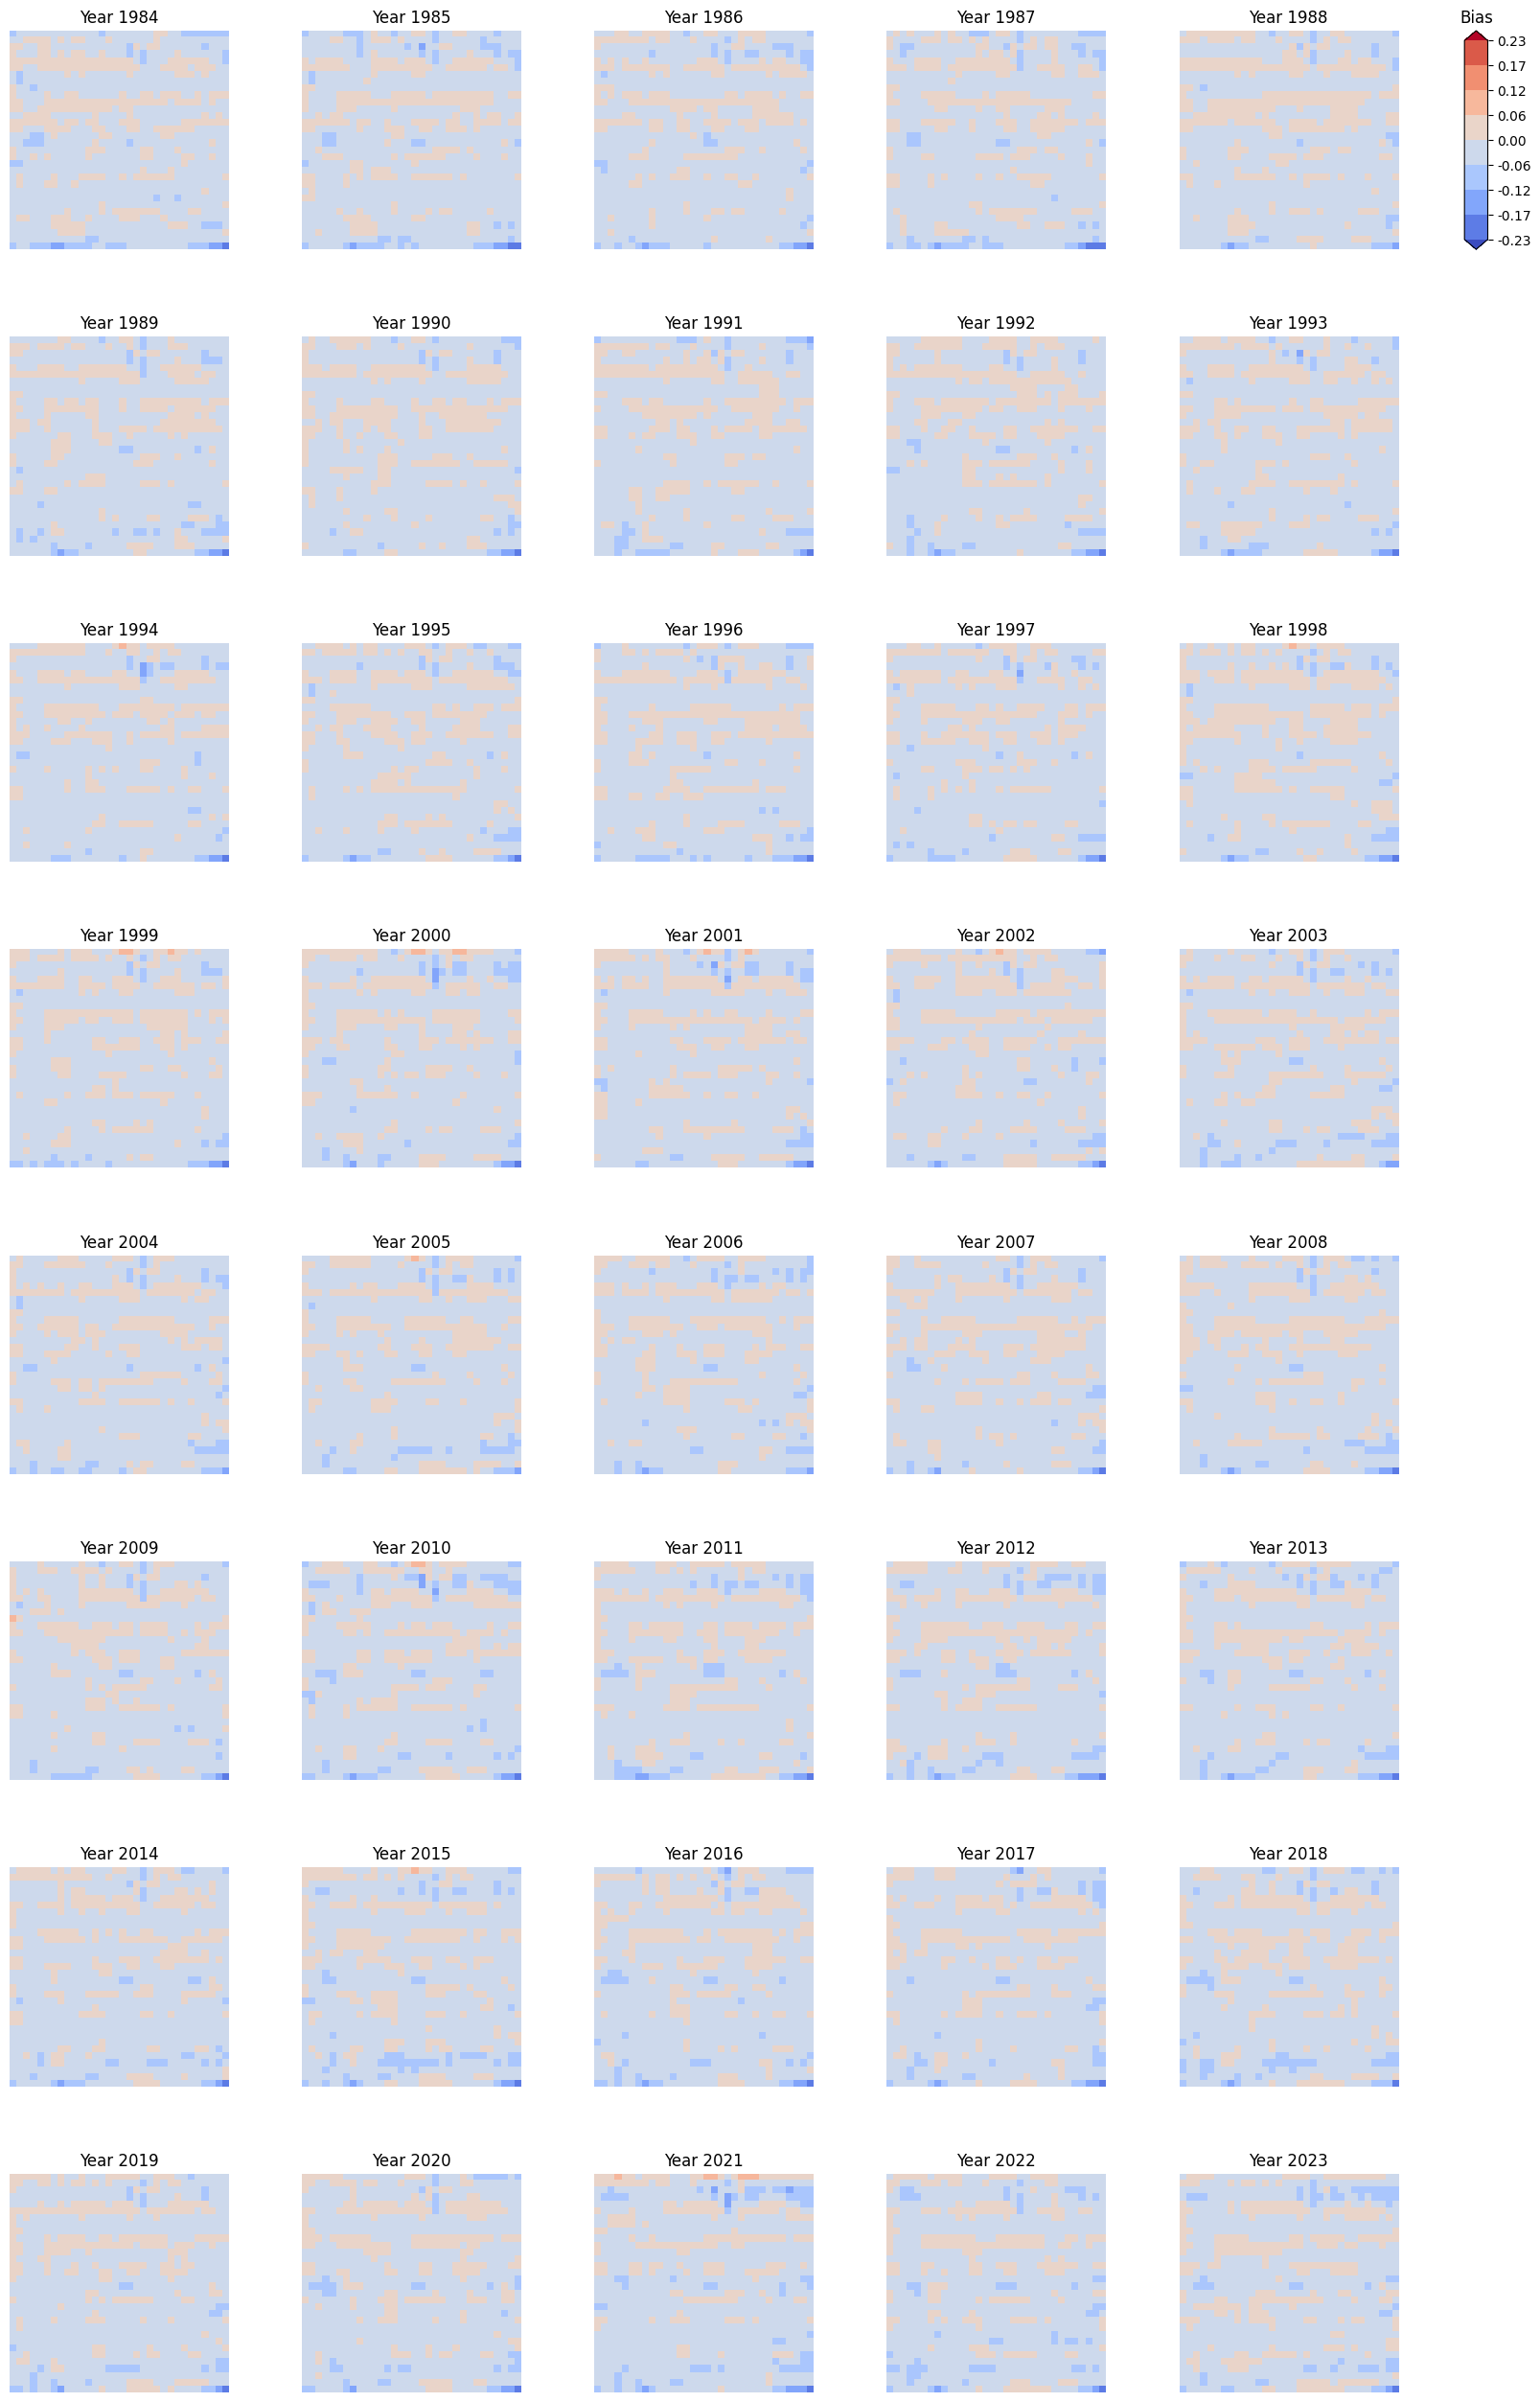

In [217]:
error_images["edsr_bias"] = np.array(error_images["edsr_bias"])

vmina = error_images["edsr_bias"].min()
vmaxa = error_images["edsr_bias"].max()
abs_max = max(abs(vmina), abs(vmaxa))
vmin, vmax = -abs_max, abs_max

levels = np.linspace(vmin, vmax, num=9)  
cmap = plt.cm.coolwarm  
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

num_years = error_images["edsr_bias"].shape[0]

ncols = 5
nrows = int(np.ceil(num_years / ncols))

fig = plt.figure(figsize=(4 * ncols, 4 * nrows))  
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.1], wspace=0.3, hspace=0.4)

for i in range(num_years):
    ax = fig.add_subplot(gs[i // ncols, i % ncols])
    im = ax.imshow(error_images["edsr_bias"][i], cmap=cmap, norm=norm)
    ax.set_title(f'Year {1984 + i}')  
    ax.axis('off')

last_row_index = nrows - 1
last_col_index = (num_years - 1) % ncols  

cbar_ax = fig.add_subplot(gs[0, -1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', ticks=levels, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])
cbar_ax.set_title('Bias', fontsize=12)

plt.show()


# Cumulative Bias from 1984 to 2023


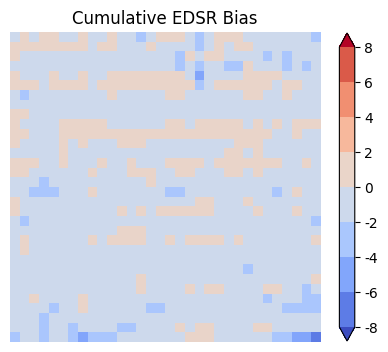

In [218]:
cum_bias_image = np.array(error_images["edsr_bias"]).sum(axis=0)
cbar_min = cum_bias_image.min()
cbar_max = cum_bias_image.max()
abs_max = max(abs(cbar_min), abs(cbar_max))
vmin, vmax = -abs_max, abs_max
cmap = plt.cm.coolwarm
levels = np.linspace(vmin, vmax, num=9)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')
fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(cum_bias_image, cmap=cmap, norm=norm)
ax.set_title('Cumulative EDSR Bias')
ax.axis('off')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.0f}' for lvl in levels])

plt.show()

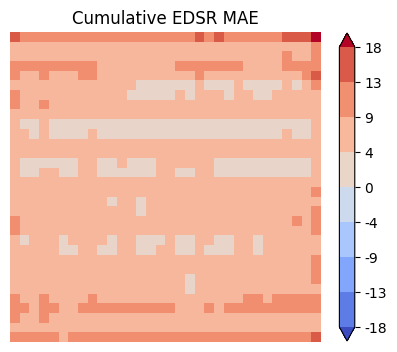

In [219]:
# cumulative mae over time plot
cumulative_mae = np.array(error_images["edsr"]).sum(axis=0)
min_val = cumulative_mae.min()
max_val = cumulative_mae.max()
max_val = max(abs(min_val), abs(max_val))
levels = np.linspace(-max_val, max_val, num=9)
cmap = plt.cm.coolwarm
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(cumulative_mae, cmap=cmap, norm=norm)
ax.set_title('Cumulative EDSR MAE')
ax.axis('off')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.0f}' for lvl in levels])

plt.show()


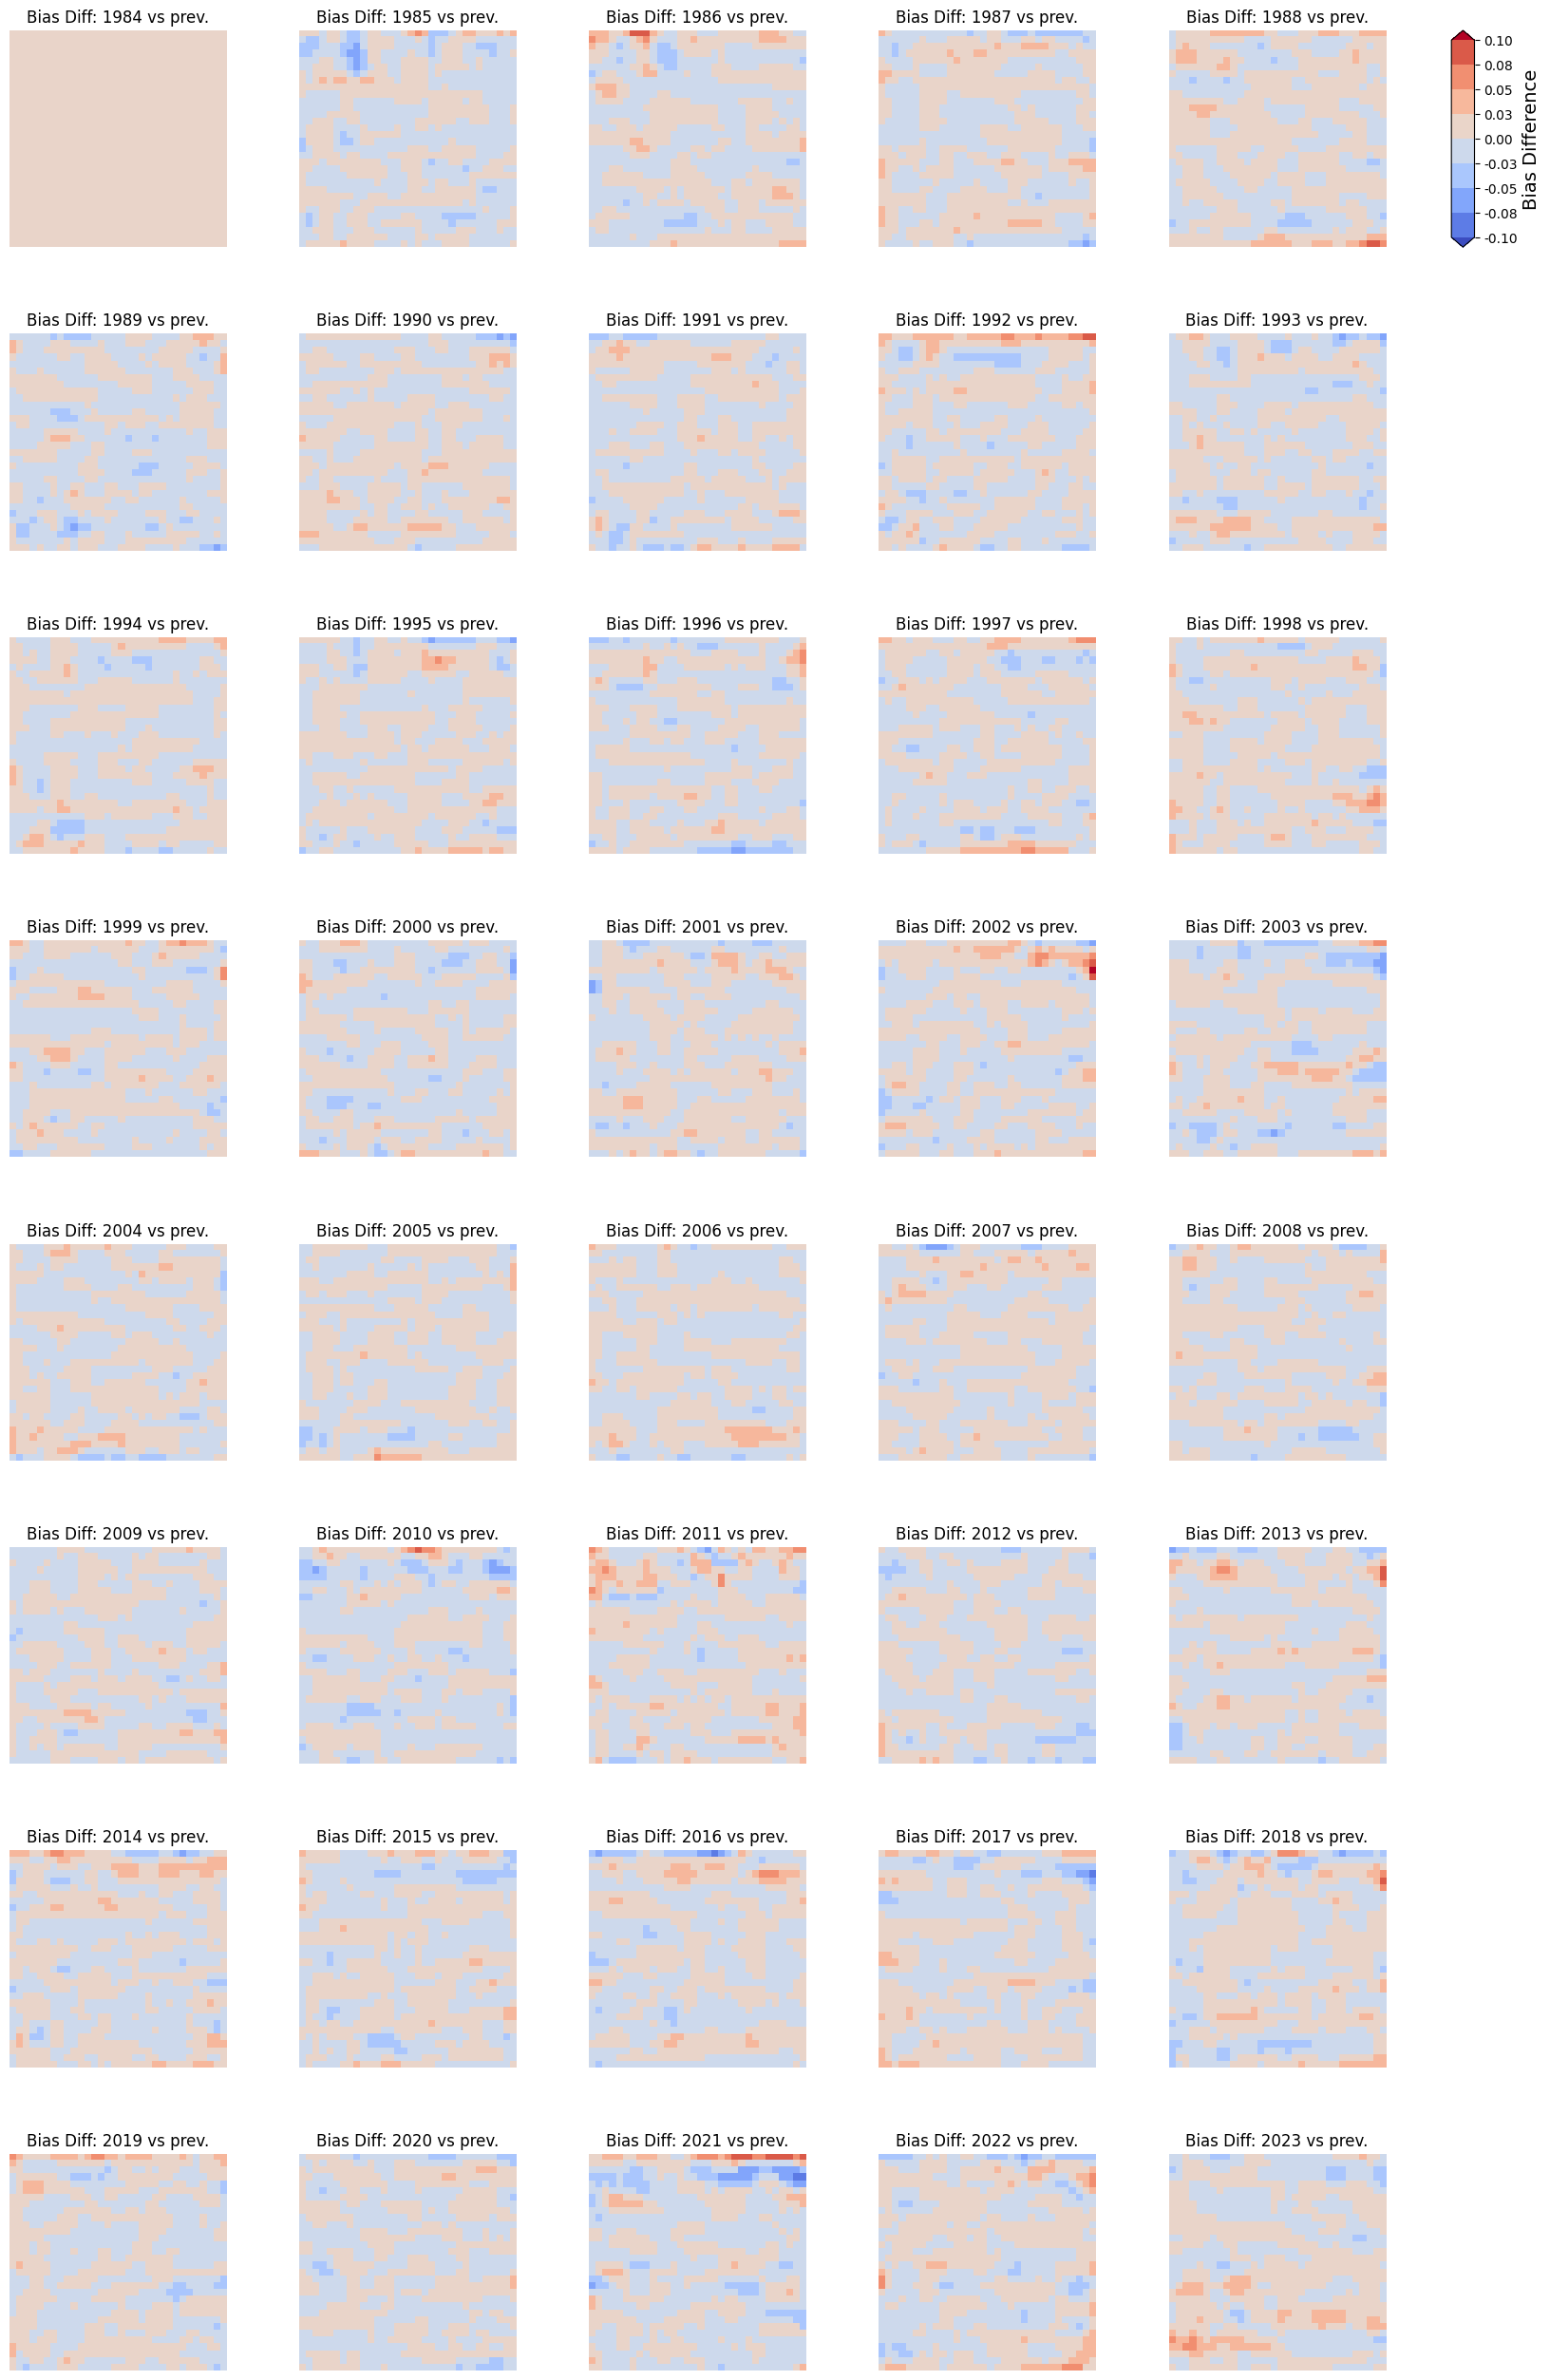

In [220]:
diff_biases = [error_images['edsr_bias'][i + 1] - error_images['edsr_bias'][i] for i in range(len(years)-1)]
diff_biases.insert(0, np.zeros_like(diff_biases[0]))

max_diff = max([np.abs(diff).max() for diff in diff_biases])
levels = np.linspace(-max_diff, max_diff, num=9)
cmap = plt.cm.coolwarm
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')


ncols = 5
nrows = int(np.ceil(num_years / ncols))

fig = plt.figure(figsize=(4 * ncols, 4 * nrows))  
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.1], wspace=0.3, hspace=0.4)

axes = []
for i in range(8):
    for j in range(5):
        idx = i * 5 + j
        ax = fig.add_subplot(gs[i, j])
        if idx < len(diff_biases):
            im = ax.imshow(diff_biases[idx], cmap=cmap, norm=norm)
            ax.set_title(f'Bias Diff: {years[idx]} vs prev.', fontsize=12)
        else:
            ax.axis('off')
        ax.axis('off')
        axes.append(ax)

# Add colorbar only to the first row of the last column
n_rows = len(axes) // 5
cbar_ax = fig.add_subplot(gs[0, -1])  # Spanning all rows in the last column
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', ticks=levels, shrink=0.8, aspect=20)
cbar.set_label('Bias Difference', fontsize=14)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])

#
# plt.tight_layout()
plt.show()



# Bias over time

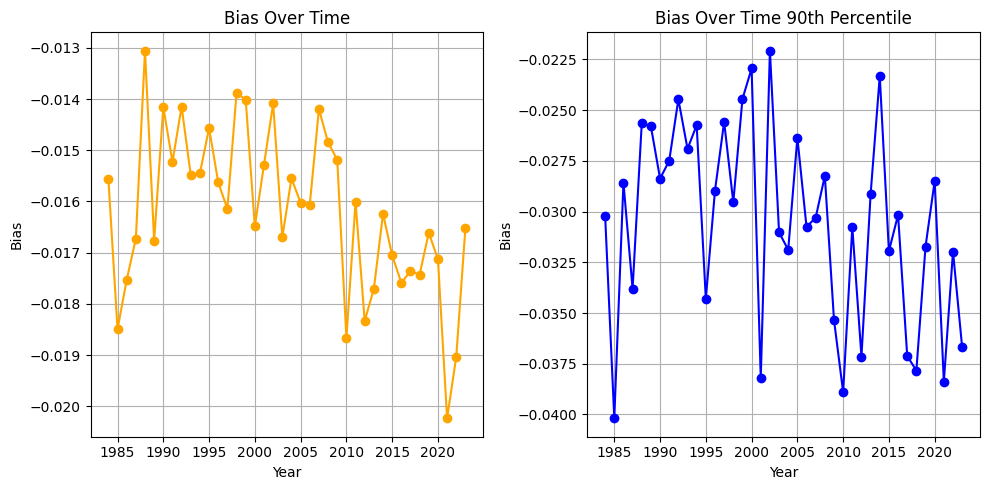

In [221]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(years, bias_per_year["edsr"], 'o-', label='EDSR', color='orange')
#ax[0].plot(years, bias_per_year["bicubic"], 'o-', label='Bicubic ', color='blue')
ax[0].set_title('Bias Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Bias')
ax[0].grid(True)

#ax[1].plot(years, bias_per_year["bicubic_90th"], 'o-', label='Bicubic 90th', color='orange')
ax[1].plot(years, bias_per_year["edsr_90th"], 'o-', label='EDSR 90th ', color='blue')
ax[1].set_title('Bias Over Time 90th Percentile')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bias')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Error over Time for one low res Pixel


In [222]:
lr_grid_size = 32 // SCALING_FACTOR  
n_lr_pixels = lr_grid_size ** 2

mse_per_pixel = {i: [] for i in range(n_lr_pixels)}
mae_per_pixel = {i: [] for i in range(n_lr_pixels)}

for i in range(n_lr_pixels):
    row, col = divmod(i, lr_grid_size) 
    for year in years:
        one_px_gt = ws_dict[year]['Ground Truth'][
            :, 
            row * SCALING_FACTOR : (row + 1) * SCALING_FACTOR,
            col * SCALING_FACTOR : (col + 1) * SCALING_FACTOR
        ]
        one_px_edsr = ws_dict[year]['EDSR'][
            :, 
            row * SCALING_FACTOR : (row + 1) * SCALING_FACTOR,
            col * SCALING_FACTOR : (col + 1) * SCALING_FACTOR
        ]
        
        one_pixel_mse, one_pixel_mae = get_metrics(one_px_edsr, one_px_gt)
        
        mse_per_pixel[i].append(one_pixel_mse)
        mae_per_pixel[i].append(one_pixel_mae)

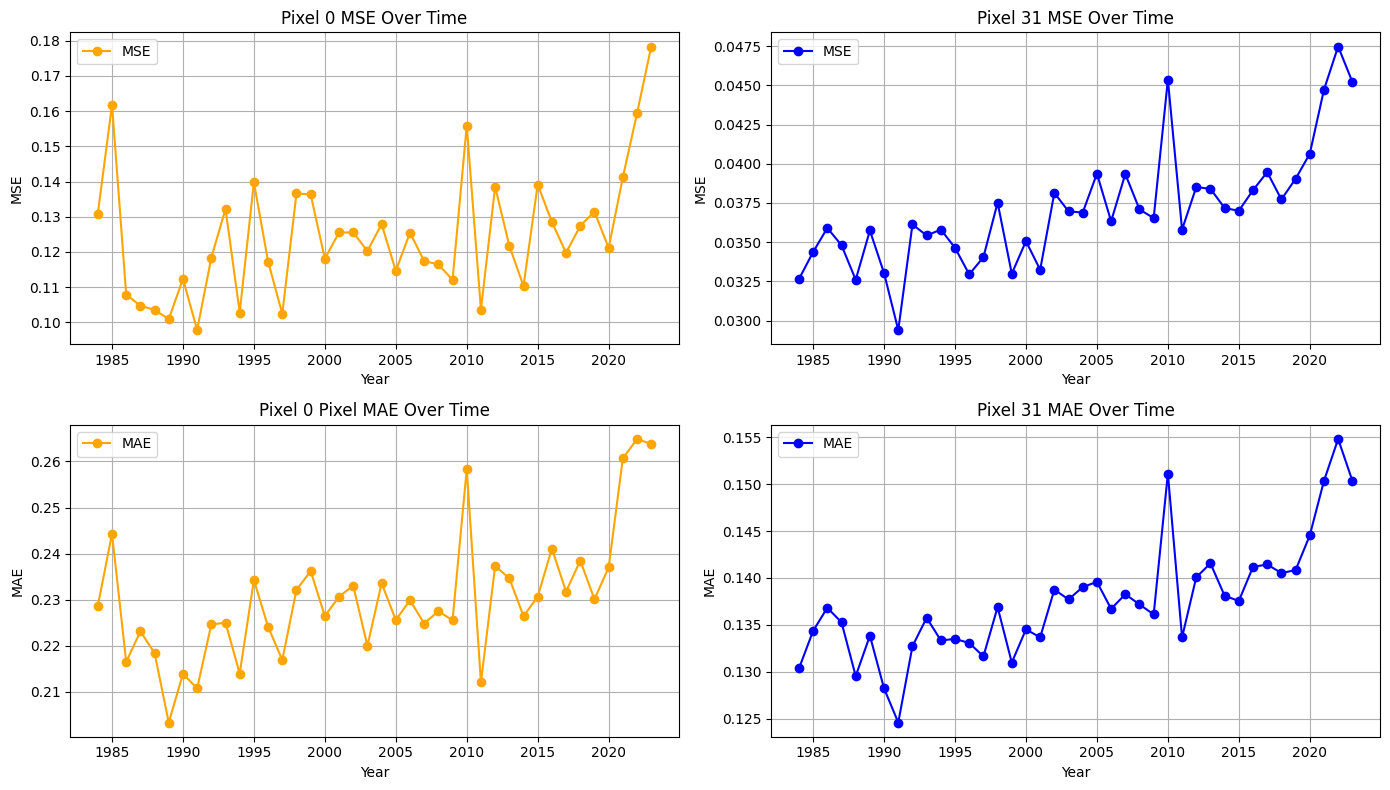

In [223]:
# plot first and last pixel error over time
first_pixel, second_pixel = 0, 63//2
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0, 0].plot(years, mse_per_pixel[first_pixel], 'o-', label='MSE', color='orange')
ax[0, 0].set_title(f'Pixel {list(mse_per_pixel.keys())[first_pixel]} MSE Over Time')
ax[0, 0].set_xlabel('Year')
ax[0, 0].set_ylabel('MSE')
ax[0, 0].legend() 
ax[0, 0].grid(True)

ax[0, 1].plot(years, mse_per_pixel[second_pixel], 'o-', label='MSE', color='blue')
ax[0, 1].set_title(f'Pixel {list(mse_per_pixel.keys())[second_pixel]} MSE Over Time')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('MSE')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].plot(years, mae_per_pixel[first_pixel], 'o-', label='MAE', color='orange')
ax[1, 0].set_title(f'Pixel {list(mse_per_pixel.keys())[first_pixel]} Pixel MAE Over Time')
ax[1, 0].set_xlabel('Year')
ax[1, 0].set_ylabel('MAE')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].plot(years, mae_per_pixel[second_pixel], 'o-', label='MAE', color='blue')
ax[1, 1].set_title(f"Pixel {list(mse_per_pixel.keys())[second_pixel]} MAE Over Time")
ax[1, 1].set_xlabel('Year')
ax[1, 1].set_ylabel('MAE')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()



# Correlation of Mean Wind Speed and Model Error


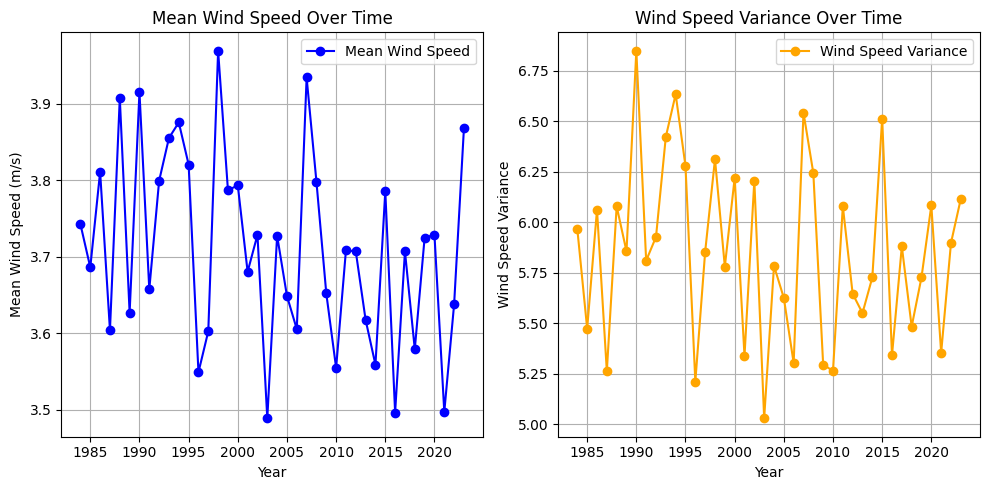

In [224]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot Mean Wind Speed with Standard Deviation Range
gt_stats['mean'] = np.array(gt_stats['mean'])
gt_stats['var'] = np.array(gt_stats['var'])
gt_stats['std'] = np.array(gt_stats['std'])
ax[0].plot(years, gt_stats['mean'], 'o-', label='Mean Wind Speed', color='blue')
"""
ax[0].fill_between(
    years,
    gt_stats['mean'] - gt_stats['std'],  
    gt_stats['mean'] + gt_stats['std'], 
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
)
"""
ax[0].set_title('Mean Wind Speed Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Mean Wind Speed (m/s)')
ax[0].legend()
ax[0].grid(True)

# Plot Wind Speed Variance Over Time
ax[1].plot(years, gt_stats['var'], 'o-', label='Wind Speed Variance', color='orange')
ax[1].set_title('Wind Speed Variance Over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Wind Speed Variance')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [225]:
mse_corr, p_mse = pearsonr(gt_stats['mean'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['mean'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['mean'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['mean'], maes['Bicubic'])

print(f"Correlation between Mean Wind Speed and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Mean Wind Speed and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")


Correlation between Mean Wind Speed and EDSR MSE: -0.2829 with p-value: 0.0769
Correlation between Mean Wind Speed and EDSR MAE: -0.4069 with p-value: 0.0092
Correlation between Mean Wind Speed and Bicubic MSE: 0.5636 with p-value: 0.0002
Correlation between Mean Wind Speed and Bicubic MAE: 0.3849 with p-value: 0.0142


In [226]:
mse_corr, p_mse = pearsonr(gt_stats['var'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['var'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['var'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['var'], maes['Bicubic'])

print(f"Correlation between Wind Speed Variance and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Wind Speed Variance and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")

Correlation between Wind Speed Variance and EDSR MSE: -0.1816 with p-value: 0.2622
Correlation between Wind Speed Variance and EDSR MAE: -0.3004 with p-value: 0.0596
Correlation between Wind Speed Variance and Bicubic MSE: 0.4795 with p-value: 0.0017
Correlation between Wind Speed Variance and Bicubic MAE: 0.3588 with p-value: 0.0230


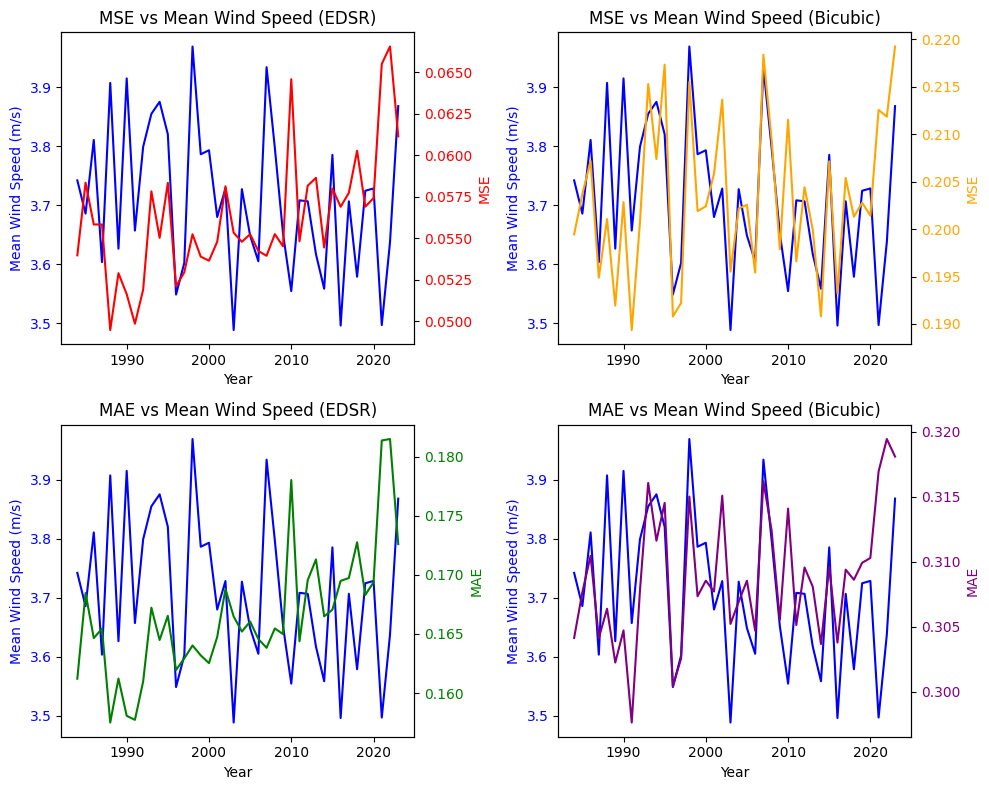

In [227]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# MSE vs Mean Wind Speed (EDSR)
ax[0, 0].plot(years, gt_stats['mean'],  color='blue', label='Mean Wind Speed')
ax[0, 0].set_xlabel('Year')
ax[0, 0].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[0, 0].tick_params(axis='y', labelcolor='blue')
ax[0, 0].set_title('MSE vs Mean Wind Speed (EDSR)')

ax2 = ax[0, 0].twinx()
ax2.plot(years, mses['EDSR'],  color='red', label='MSE (EDSR)')
ax2.set_ylabel('MSE', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False)  # Disables grid on right axis to avoid clutter

# MSE vs Mean Wind Speed (Bicubic)
ax[0, 1].plot(years, gt_stats['mean'], color='blue', label='Mean Wind Speed')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[0, 1].tick_params(axis='y', labelcolor='blue')
ax[0, 1].set_title('MSE vs Mean Wind Speed (Bicubic)')

ax2 = ax[0, 1].twinx()
ax2.plot(years, mses['Bicubic'],  color='orange', label='MSE (Bicubic)')
ax2.set_ylabel('MSE', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.grid(False)

# MAE vs Mean Wind Speed (EDSR)
ax[1, 0].plot(years, gt_stats['mean'],  color='blue', label='Mean Wind Speed')
ax[1, 0].set_xlabel('Year')
ax[1, 0].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[1, 0].tick_params(axis='y', labelcolor='blue')
ax[1, 0].set_title('MAE vs Mean Wind Speed (EDSR)')

ax2 = ax[1, 0].twinx()
ax2.plot(years, maes['EDSR'],  color='green', label='MAE (EDSR)')
ax2.set_ylabel('MAE', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(False)

# MAE vs Mean Wind Speed (Bicubic)
ax[1, 1].plot(years, gt_stats['mean'], color='blue', label='Mean Wind Speed')
ax[1, 1].set_xlabel('Year')
ax[1, 1].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[1, 1].tick_params(axis='y', labelcolor='blue')
ax[1, 1].set_title('MAE vs Mean Wind Speed (Bicubic)')

ax2 = ax[1, 1].twinx()
ax2.plot(years, maes['Bicubic'], color='purple', label='MAE (Bicubic)')
ax2.set_ylabel('MAE', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.grid(False)

plt.tight_layout()
plt.show()


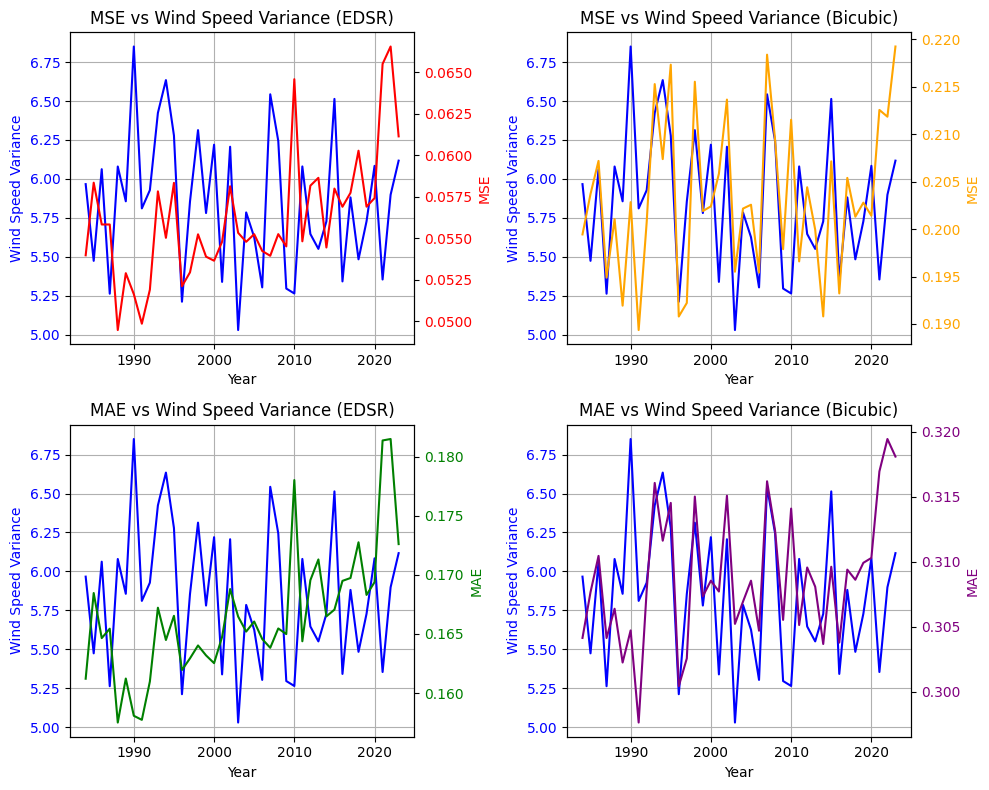

In [228]:
# same for variance
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# MSE vs Wind Speed Variance (EDSR)
ax[0, 0].plot(years, gt_stats['var'],  color='blue', label='Wind Speed Variance')
ax[0, 0].set_xlabel('Year')
ax[0, 0].set_ylabel('Wind Speed Variance', color='blue')
ax[0, 0].tick_params(axis='y', labelcolor='blue')
ax[0, 0].set_title('MSE vs Wind Speed Variance (EDSR)')
ax[0, 0].grid(True)

ax2 = ax[0, 0].twinx()
ax2.plot(years, mses['EDSR'],  color='red', label='MSE (EDSR)')
ax2.set_ylabel('MSE', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False)  # Disables grid on right axis to avoid clutter

# MSE vs Wind Speed Variance (Bicubic)
ax[0, 1].plot(years, gt_stats['var'], color='blue', label='Wind Speed Variance')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('Wind Speed Variance', color='blue')
ax[0, 1].tick_params(axis='y', labelcolor='blue')
ax[0, 1].set_title('MSE vs Wind Speed Variance (Bicubic)')
ax[0, 1].grid(True)

ax2 = ax[0, 1].twinx()
ax2.plot(years, mses['Bicubic'],  color='orange', label='MSE (Bicubic)')
ax2.set_ylabel('MSE', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.grid(False)

# MAE vs Wind Speed Variance (EDSR)
ax[1, 0].plot(years, gt_stats['var'],  color='blue', label='Wind Speed Variance')
ax[1, 0].set_xlabel('Year')
ax[1, 0].set_ylabel('Wind Speed Variance', color='blue')
ax[1, 0].tick_params(axis='y', labelcolor='blue')
ax[1, 0].set_title('MAE vs Wind Speed Variance (EDSR)')
ax[1, 0].grid(True)

ax2 = ax[1, 0].twinx()
ax2.plot(years, maes['EDSR'],  color='green', label='MAE (EDSR)')
ax2.set_ylabel('MAE', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(False)

# MAE vs Wind Speed Variance (Bicubic)
ax[1, 1].plot(years, gt_stats['var'], color='blue', label='Wind Speed Variance')
ax[1, 1].set_xlabel('Year')
ax[1, 1].set_ylabel('Wind Speed Variance', color='blue')
ax[1, 1].tick_params(axis='y', labelcolor='blue')
ax[1, 1].set_title('MAE vs Wind Speed Variance (Bicubic)')
ax[1, 1].grid(True)

ax2 = ax[1, 1].twinx()
ax2.plot(years, maes['Bicubic'], color='purple', label='MAE (Bicubic)')
ax2.set_ylabel('MAE', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.grid(False)

plt.tight_layout()
plt.show()

# Fitting Exponetnial Weibull Distributitions to predicted wind speed, monitor parameter change over time

In [ ]:
#fit exponentiated weibull to ws_dict[1984]['EDSR'] and ws_dict[1984]['Ground Truth']

min_gt = ws_dict[1984]['Ground Truth'].min()
max_gt = ws_dict[1984]['Ground Truth'].max()
x_gt = np.linspace(min_gt, max_gt, 1000)

min_edsr = ws_dict[1984]['EDSR'].min()
max_edsr = ws_dict[1984]['EDSR'].max()
x_edsr = np.linspace(min_edsr, max_edsr, 1000)

a1, c1, loc1, scale1 = exponweib.fit(ws_dict[1984]['EDSR'])
a2, c2, loc2, scale2 = exponweib.fit(ws_dict[1984]['Ground Truth'])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(ws_dict[1984]['EDSR'].flatten(), kde=True, ax=ax[0], color='orange', stat='density')
sns.histplot(ws_dict[1984]['Ground Truth'].flatten(), kde=True, ax=ax[1], color='blue',stat='density')

pdf_edsr = exponweib.pdf(x_edsr, a1, c1, loc=loc1, scale=scale1)
pdf_gt = exponweib.pdf(x_gt, a2, c2, loc=loc2, scale=scale2)
ax[0].plot(x_edsr, pdf_edsr, color='red', label='Fitted Distribution')
ax[1].plot(x_gt, pdf_gt, color='red', label='Fitted Distribution')
ax[0].set_title('EDSR Wind Speed Distribution')
ax[0].set_xlabel('Wind Speed (m/s)')
ax[0].set_ylabel('Density')
ax[0].legend()

ax[1].set_title('Ground Truth Wind Speed Distribution')
ax[1].set_xlabel('Wind Speed (m/s)')
ax[1].set_ylabel('Density')
ax[1].legend()



In [ ]:
years2 = list(range(1984, 2024,  5))
years2.append(2023)
#years2 = years
print(years2)
print(years)

[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [ ]:

params_gt = {year : exponweib.fit(ws_dict[year]['Ground Truth']) for year in years2}
params_edsr = {year : exponweib.fit(ws_dict[year]['EDSR']) for year in years2}


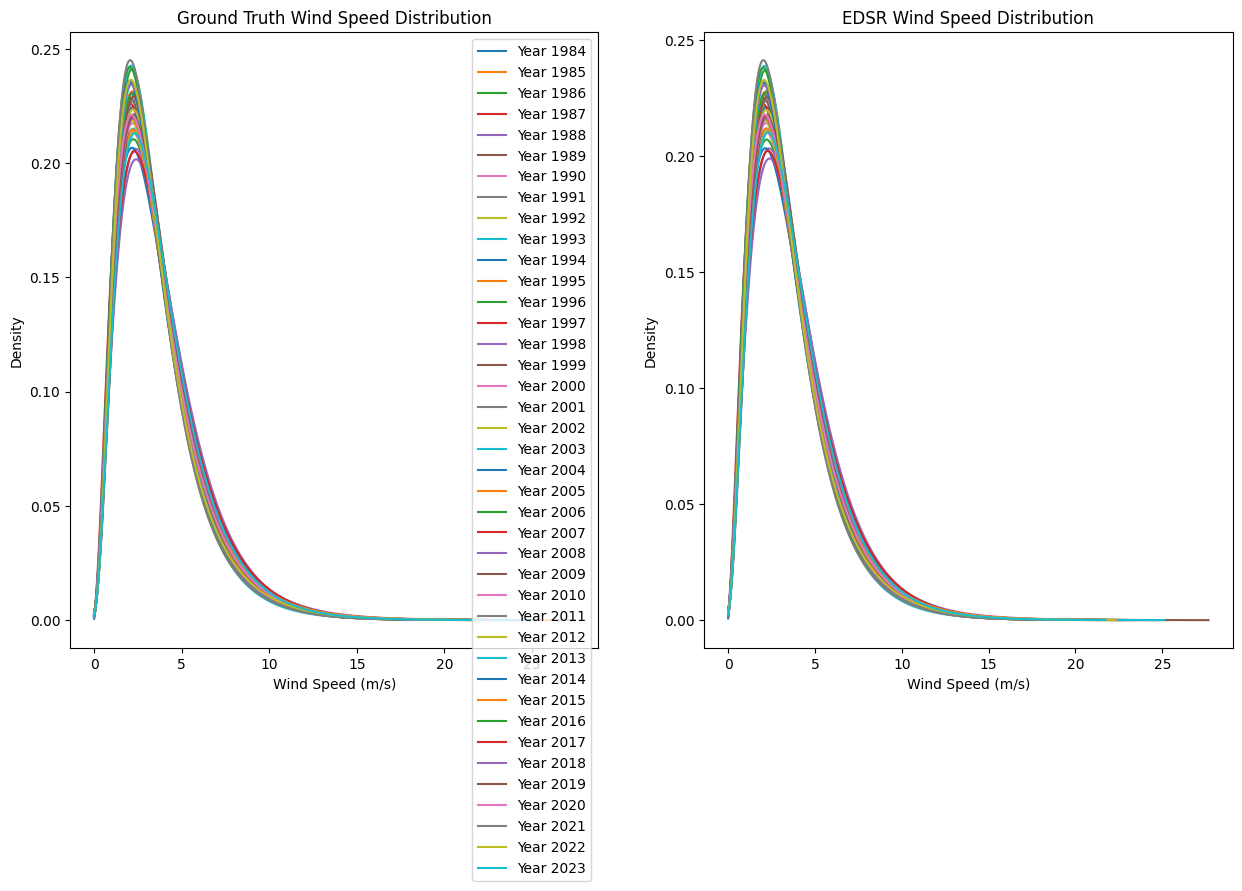

In [ ]:
# plot pdfs for each year
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
colors = sns.color_palette('tab10', len(years2))
for i,year in enumerate(years2):
    x_gt = np.linspace(ws_dict[year]['Ground Truth'].min(), ws_dict[year]['Ground Truth'].max(), 1000)
    x_edsr = np.linspace(ws_dict[year]['EDSR'].min(), ws_dict[year]['EDSR'].max(), 1000)
    pdf_gt = exponweib.pdf(x_gt, *params_gt[year])
    pdf_edsr = exponweib.pdf(x_edsr, *params_edsr[year])
    ax[0].plot(x_gt, pdf_gt, label=f'Year {year}' ,color=colors[i])
    ax[1].plot(x_edsr, pdf_edsr, label=f'Year {year}', color=colors[i])
    
ax[0].set_title('Ground Truth Wind Speed Distribution')
ax[0].set_xlabel('Wind Speed (m/s)')
ax[0].set_ylabel('Density')
#ax[0].legend()
ax[1].set_title('EDSR Wind Speed Distribution')
ax[1].set_xlabel('Wind Speed (m/s)')
ax[1].set_ylabel('Density')
#ax[1].legend()

plt.show()


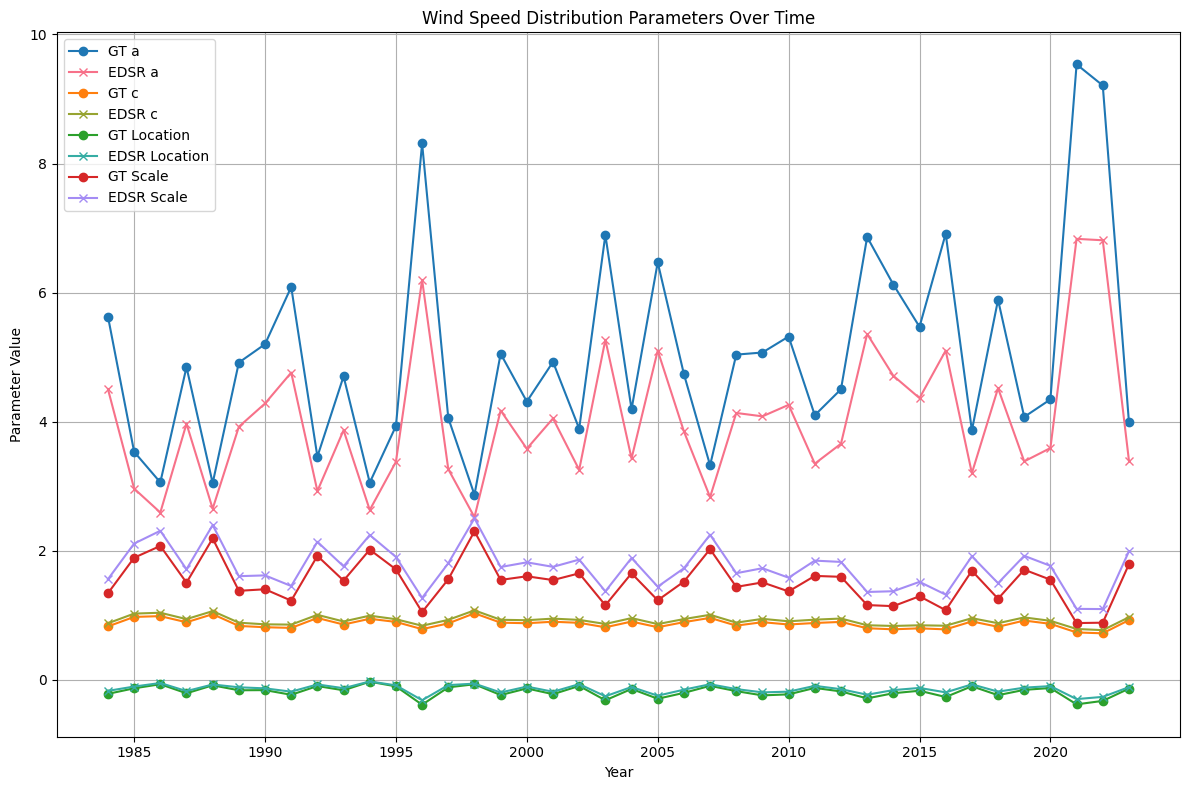

In [ ]:
params_gt_array = np.array(list(params_gt.values()))  
params_edsr_array = np.array(list(params_edsr.values()))  

fig, ax = plt.subplots(figsize=(12, 8))
colors_gt = sns.color_palette('tab10', 4)
colors_edsr = sns.color_palette('husl', 4)
labels = ['a', 'c', 'Location', 'Scale']
for i in range(4):
    ax.plot(years2, params_gt_array[:, i], label=f'GT {labels[i]}', color=colors_gt[i], marker='o')
    ax.plot(years2, params_edsr_array[:, i], label=f'EDSR {labels[i]}', color=colors_edsr[i], marker='x')

ax.set_title('Wind Speed Distribution Parameters Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Parameter Value')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Regression on model error over time

## Linear regression

### MSE

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress


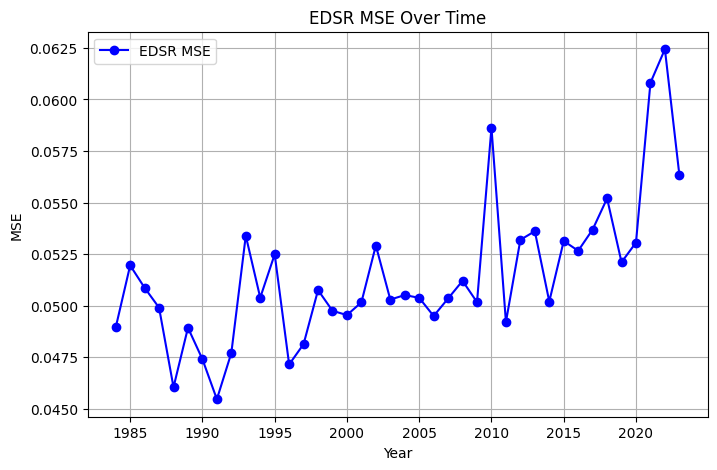

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0002, 
Intercept: -0.3521, 
R-value: 0.6633, 
P-value: 0.00000309, 
Std. Error: 0.0000


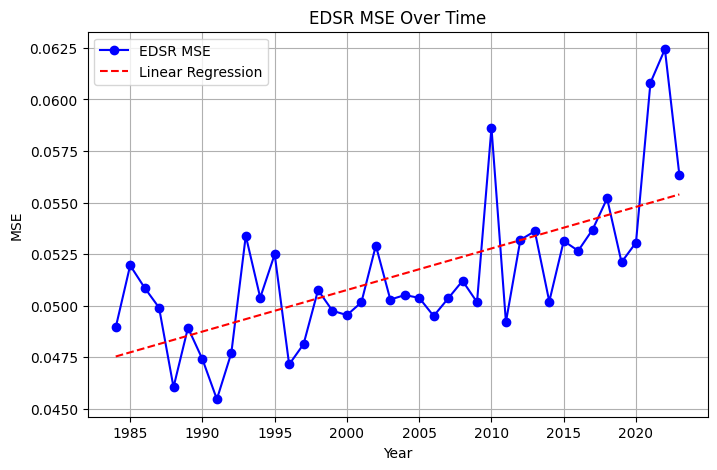

In [ ]:
res = linregress(years, mses['EDSR'])
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()


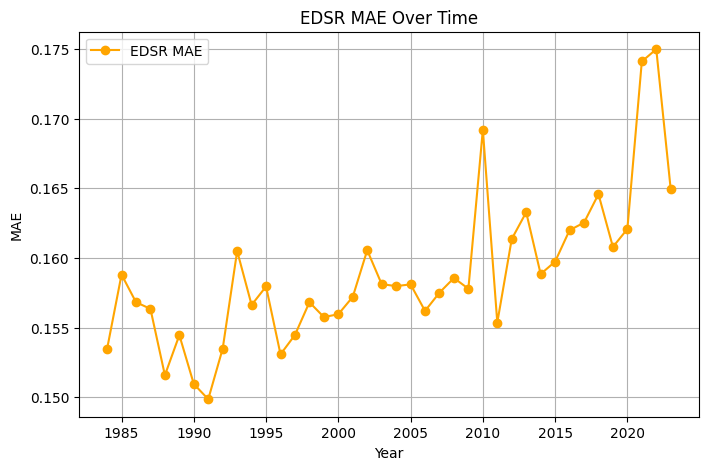

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='orange')
#ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0003, 
Intercept: -0.5159, 
R-value: 0.7309, 
P-value: 0.00000009, 
Std. Error: 0.0001


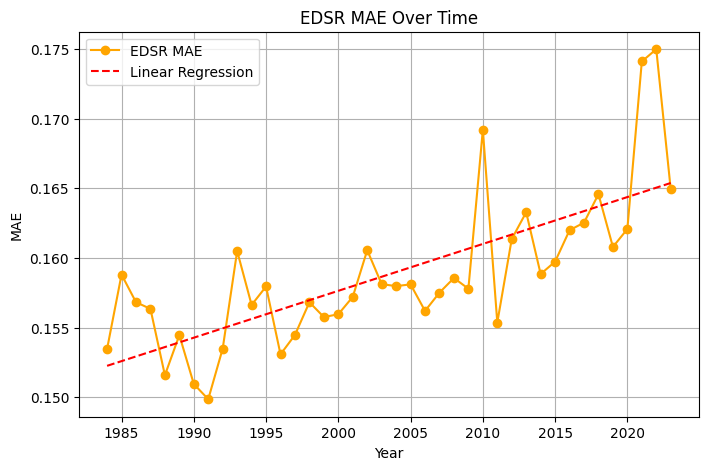

In [ ]:
res = linregress(years, maes['EDSR'])
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='orange')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

Linear Regression Coefficient: 0.0002, Intercept: -0.3521
R² Score: 0.4400


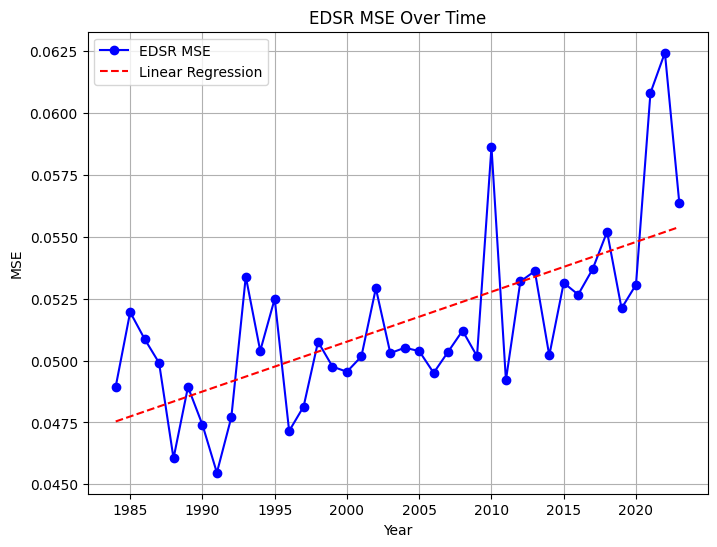

In [ ]:
X = np.array(years).reshape(-1, 1)
y = np.array(mses['EDSR']).reshape(-1, 1)
reg = LinearRegression().fit(X, y)
print(f"Linear Regression Coefficient: {reg.coef_[0][0]:.4f}, Intercept: {reg.intercept_[0]:.4f}")
print(f"R² Score: {reg.score(X, y):.4f}")
# get p value for linear regression
#plot linear regression
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, reg.predict(X), '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()


### MAE

Linear Regression Coefficient: 0.0003, Intercept: -0.5159
R² Score: 0.5341


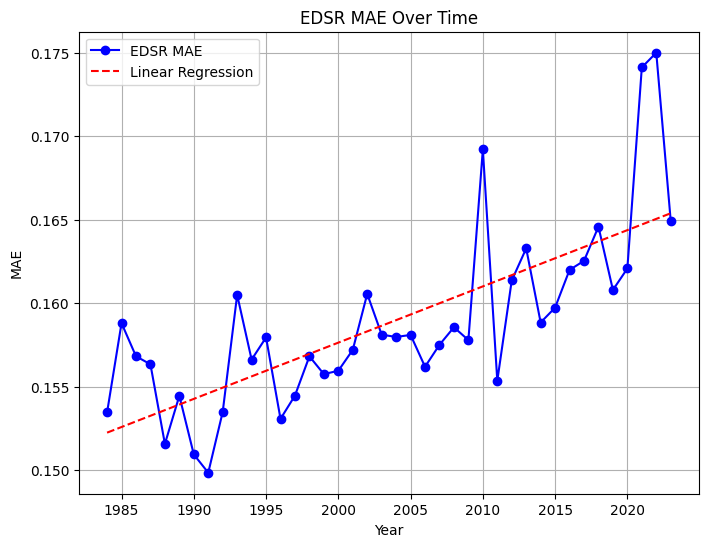

In [ ]:
y = np.array(maes['EDSR']).reshape(-1, 1)
reg = LinearRegression().fit(X, y)
print(f"Linear Regression Coefficient: {reg.coef_[0][0]:.4f}, Intercept: {reg.intercept_[0]:.4f}")
print(f"R² Score: {reg.score(X, y):.4f}")
#plot linear regression
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, reg.predict(X), '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()


## Exp Regression


### MSE

Exponential Regression Coefficients: [ 1.66599590e-04 -6.63742077e-01  6.58083257e+02]
R² Score for Exponential Regression: 0.5413


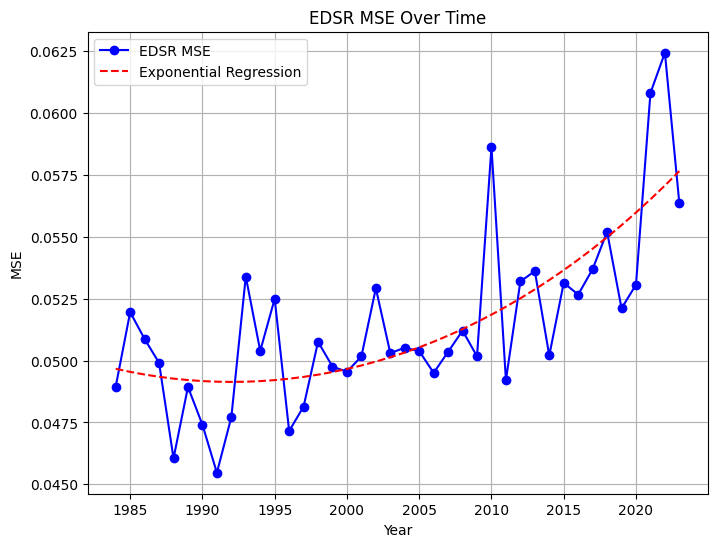

Predicted MSE for 2024: 0.0583


In [ ]:
mses['EDSR'] = np.array(mses['EDSR'])
fit = np.polyfit(years, np.log(mses['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mse = np.exp(np.polyval(fit, years))
# get residual error
r_squared = 1 - (np.sum((predicted_mse - mses['EDSR'])**2) / np.sum((mses['EDSR'] - mses['EDSR'].mean())**2))

print(f"R² Score for Exponential Regression: {r_squared:.4f}")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, predicted_mse, '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

#now predict for 2024
predicted_mse_2024 = np.exp(np.polyval(fit, [2024]))
print(f"Predicted MSE for 2024: {predicted_mse_2024[0]:.4f}")



### MAE

Exponential Regression Coefficients: [ 7.30750336e-05 -2.90715253e-01  2.87273638e+02]
R² Score for Exponential Regression: 0.6093


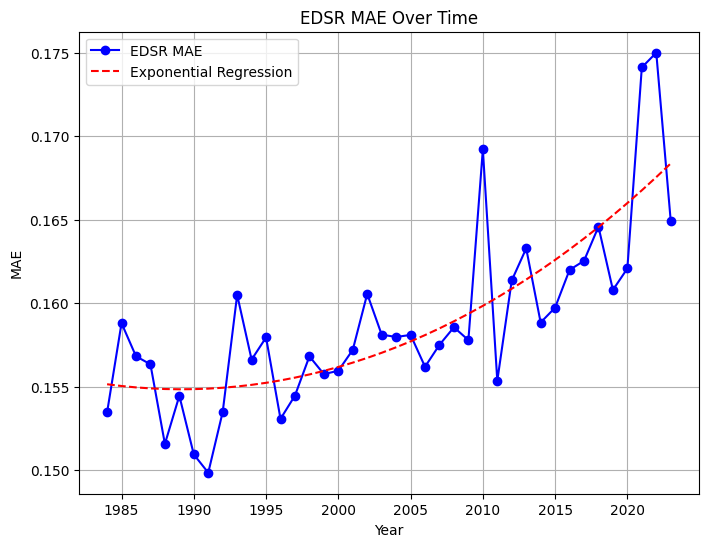

In [ ]:
maes['EDSR'] = np.array(maes['EDSR'])
fit = np.polyfit(years, np.log(maes['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mae = np.exp(np.polyval(fit, years))

ss_res = np.sum((maes['EDSR'] - predicted_mae) ** 2)
ss_tot = np.sum((maes['EDSR'] - np.mean(maes['EDSR'])) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² Score for Exponential Regression: {r_squared:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))    
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, predicted_mae, '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()



# Log regression


## MSE

Logarithmic Regression Coefficients: [  37.31652084 -567.00314097 2153.87105061]
R² Score for Logarithmic Regression: 0.5386


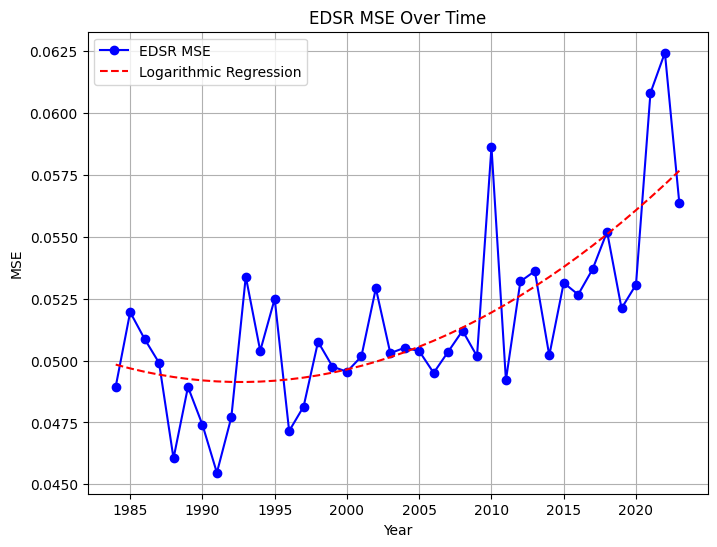

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mses['EDSR'] = np.array(mses['EDSR'])

fit_log = np.polyfit(np.log(years), mses['EDSR'], 2)
print(f"Logarithmic Regression Coefficients: {fit_log}")

predicted_mse_log = np.polyval(fit_log, np.log(years))
r_squared_log = 1 - (np.sum((predicted_mse_log - mses['EDSR'])**2) / np.sum((mses['EDSR'] - mses['EDSR'].mean())**2))

print(f"R² Score for Logarithmic Regression: {r_squared_log:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, predicted_mse_log, '--', label='Logarithmic Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()



## MAE

Logarithmic Regression Coefficients: [  49.18201434 -747.14973219 2837.74056073]
R² Score for Logarithmic Regression: 0.6084


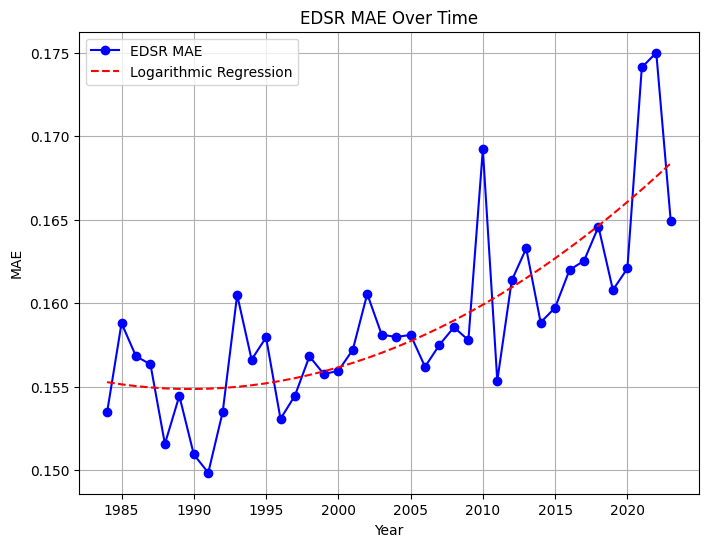

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


maes['EDSR'] = np.array(maes['EDSR'])

fit_log = np.polyfit(np.log(years), maes['EDSR'], 2)
print(f"Logarithmic Regression Coefficients: {fit_log}")

predicted_mae_log = np.polyval(fit_log, np.log(years))
r_squared_log = 1 - (np.sum((predicted_mae_log - maes['EDSR'])**2) / np.sum((maes['EDSR'] - maes['EDSR'].mean())**2))

print(f"R² Score for Logarithmic Regression: {r_squared_log:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, predicted_mae_log, '--', label='Logarithmic Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

